# Bike Sharing Demand - Model Experimentation

This notebook trains and compares several regression strategies for predicting hourly bike rental demand (`count`), building on the conclusions of the EDA notebook (`notebooks/eda_train_analysis.ipynb`). Every model is evaluated with K-Fold cross-validation on model metrics (RMSLE, MAE, R2) and on two business-metric proxies (stockout rate, idle rate).

# 1. Imports, Preprocessing & Feature Engineering

In [134]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline

RANDOM_SEED = 42

## Load data and complete missing hourly timestamps

In [135]:
df = pd.read_csv("../data/train.csv", parse_dates=["datetime"])

original_dtypes = df.drop(columns="datetime").dtypes
df = df.set_index("datetime").sort_index()

# Reindex within each month's day 1-19 window only (not a single continuous
# range from the global min to the global max), since days 20-end of the month
# were never part of train.csv and reindexing across them would fabricate rows
# that don't belong to this dataset.
months_present = df.index.to_period("M").unique()
full_range = pd.DatetimeIndex(sorted(
    ts
    for month in months_present
    for ts in pd.date_range(month.start_time, periods=19 * 24, freq="h")
))
df = df.reindex(full_range).ffill()
df.index.name = "datetime"
df = df.reset_index().astype(original_dtypes.to_dict())

df = df.drop(columns=["casual", "registered"])

print(f"Shape after completing missing hours and dropping casual/registered: {df.shape}")
df.head()

Shape after completing missing hours and dropping casual/registered: (10944, 10)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,1


## Datetime-derived features

In [136]:
season_labels = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}
weather_labels = {
    1: "Clear/Few Clouds",
    2: "Mist/Cloudy",
    3: "Light Rain/Snow",
    4: "Heavy Rain/Snow",
}

df["season"] = df["season"].map(season_labels)
df["weather"] = df["weather"].map(weather_labels)

df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year
df["day_of_week"] = df["datetime"].dt.dayofweek

df[["season", "weather", "hour", "month", "year", "day_of_week"]].head()

,season,weather,hour,month,year,day_of_week
0,Spring,Clear/Few Clouds,0,1,2011,5
1,Spring,Clear/Few Clouds,1,1,2011,5
2,Spring,Clear/Few Clouds,2,1,2011,5
3,Spring,Clear/Few Clouds,3,1,2011,5
4,Spring,Clear/Few Clouds,4,1,2011,5


## Target transformation and feature sets

In [137]:
df["count_log"] = np.log1p(df["count"])

categorical_features = ["season", "weather"]
numerical_features_base = ["temp", "atemp", "day_of_week", "humidity", "hour", "month", "year", "windspeed", "workingday", "holiday"]
numerical_features_linear = ["temp", "day_of_week", "humidity", "hour", "month", "year", "windspeed", "workingday"]  # atemp dropped: collinear with temp

encoder = OneHotEncoder(drop="first", sparse_output=False)
encoded_array = encoder.fit_transform(df[categorical_features])
encoded = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(categorical_features),
    index=df.index,
)


def sanitize_column_names(frame):
    frame = frame.copy()
    frame.columns = [re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)) for col in frame.columns]
    return frame


X_base = sanitize_column_names(pd.concat([df[numerical_features_base], encoded], axis=1))
X_linear = sanitize_column_names(pd.concat([df[numerical_features_linear], encoded], axis=1))

y_log = df["count_log"]
y_count = df["count"]

print(f"X_base shape: {X_base.shape}")
print(f"X_linear shape: {X_linear.shape}")
X_base.head()

X_base shape: (10944, 16)
X_linear shape: (10944, 14)


,temp,atemp,day_of_week,humidity,hour,month,year,windspeed,workingday,holiday,season_Spring,season_Summer,season_Winter,weather_Heavy_Rain_Snow,weather_Light_Rain_Snow,weather_Mist_Cloudy
0,9.84,14.395,5,81,0,1,2011,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
1,9.02,13.635,5,80,1,1,2011,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
2,9.02,13.635,5,80,2,1,2011,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
3,9.84,14.395,5,75,3,1,2011,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
4,9.84,14.395,5,75,4,1,2011,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0


# 2. Evaluation Utilities

Cross-validation uses a walk-forward temporal split (`TimeSeriesSplit`) instead of randomly shuffled K-Fold: adjacent hours are highly autocorrelated, so a random shuffle would let the model train on hours immediately surrounding a "held-out" hour, leaking information it would never have at real prediction time (where only the past is available). Each fold's training window grows chronologically and is always followed by a later test window. One consequence: the earliest block of rows is only ever used for training and never appears in any fold's held-out set, so it has no out-of-fold prediction (`oof_pred_count` is `NaN` there) and is excluded from the business-metrics and bias analyses below.

Every model here is fit on `log1p(count)`, not on raw `count`. Since `RMSLE(y, ŷ) == RMSE(log1p(y), log1p(ŷ))`, training directly on `log1p(count)` with a standard RMSE-based loss/scorer optimizes RMSLE without any extra transformation at training time. Predictions are inverted with `expm1` and clipped at 0 (`np.maximum(expm1(y_pred_log), 0)`) before computing any metric on the original `count` scale, since `count` cannot be negative and `log1p` of a negative prediction is undefined.

In [138]:
def compute_metrics(y_true_count, y_pred_log):
    """Inverse-transform log1p predictions (clipped at 0) and compute RMSLE, MAE, R2 on the original count scale."""
    count_pred = np.maximum(np.expm1(y_pred_log), 0)

    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true_count), np.log1p(count_pred)))
    mae = mean_absolute_error(y_true_count, count_pred)
    r2 = r2_score(y_true_count, count_pred)

    return {"RMSLE": rmsle, "MAE": mae, "R2": r2}

In [139]:
def neg_rmsle_scorer(estimator, X, y_log):
    y_pred_log = estimator.predict(X)
    return -np.sqrt(mean_squared_error(y_log, y_pred_log))


def run_kfold_experiment(model, X, y_log, y_count, k=5, model_name="model"):
    """Train `model` on log1p(count) with a walk-forward temporal split
    (TimeSeriesSplit), collect train/test metrics (here "test" means the
    held-out CV fold, not the Kaggle test.csv), plot a learning curve, and
    extract feature importance (or equivalent). `X`/`y_log`/`y_count` must
    already be sorted chronologically."""
    kf = TimeSeriesSplit(n_splits=k)

    train_metrics = {"RMSLE": [], "MAE": [], "R2": []}
    test_metrics = {"RMSLE": [], "MAE": [], "R2": []}
    oof_pred_log = pd.Series(index=X.index, dtype=float)

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_log_train, y_log_test = y_log.iloc[train_idx], y_log.iloc[test_idx]
        y_count_train, y_count_test = y_count.iloc[train_idx], y_count.iloc[test_idx]

        model.fit(X_train, y_log_train)

        train_pred_log = model.predict(X_train)
        test_pred_log = model.predict(X_test)
        oof_pred_log.iloc[test_idx] = test_pred_log

        for name, value in compute_metrics(y_count_train, train_pred_log).items():
            train_metrics[name].append(value)
        for name, value in compute_metrics(y_count_test, test_pred_log).items():
            test_metrics[name].append(value)

    train_summary = {name: np.mean(values) for name, values in train_metrics.items()}
    test_summary = {name: np.mean(values) for name, values in test_metrics.items()}

    print(f"{model_name} - train (mean over {k} folds): {train_summary}")
    print(f"{model_name} - test (mean over {k} folds): {test_summary}")

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y_log, cv=TimeSeriesSplit(n_splits=k), scoring=neg_rmsle_scorer,
        train_sizes=np.linspace(0.1, 1.0, 5),
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(train_sizes, -train_scores.mean(axis=1), marker="o", label="Train RMSLE")
    ax.plot(train_sizes, -test_scores.mean(axis=1), marker="o", label="Validation RMSLE")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("RMSLE")
    ax.set_title(f"Learning curve - {model_name}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    if hasattr(model, "feature_importances_"):
        importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    elif hasattr(model, "coef_"):
        importance = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
    else:
        importance = None

    if importance is not None:
        fig, ax = plt.subplots(figsize=(6, 4))
        importance.head(15).plot(kind="barh", ax=ax)
        ax.invert_yaxis()
        ax.set_title(f"Feature importance - {model_name}")
        plt.tight_layout()
        plt.show()

    return {
        "model_name": model_name,
        "train_metrics": train_metrics,
        "train_summary": train_summary,
        "test_metrics": test_metrics,
        "test_summary": test_summary,
        "feature_importance": importance,
        "oof_pred_count": np.maximum(np.expm1(oof_pred_log), 0),
    }

# 3. Baseline Model (Random)

A random baseline that ignores all input features and predicts a value drawn uniformly at random (with replacement) from the empirical distribution of `count_log` observed in the training fold. It tests whether the models below actually learn something beyond noise sampled from the target's own distribution. Its learning curve is expected to stay flat, since it never uses `X`, and it has no feature importance (reported as `None`).

In [140]:
class RandomBaselineRegressor(BaseEstimator, RegressorMixin):
    """Predicts random draws from the empirical distribution of the training target; ignores X."""

    def __init__(self, random_state=None):
        self.random_state = random_state

    def fit(self, X, y):
        self.y_train_ = np.asarray(y)
        self.rng_ = np.random.default_rng(self.random_state)
        return self

    def predict(self, X):
        return self.rng_.choice(self.y_train_, size=len(X), replace=True)

Random Baseline - train (mean over 5 folds): {'RMSLE': np.float64(2.000426471172068), 'MAE': np.float64(141.0400566520468), 'R2': np.float64(-1.0075897607383477)}
Random Baseline - test (mean over 5 folds): {'RMSLE': np.float64(2.0638545618357655), 'MAE': np.float64(182.3140350877193), 'R2': np.float64(-0.7924190165083254)}


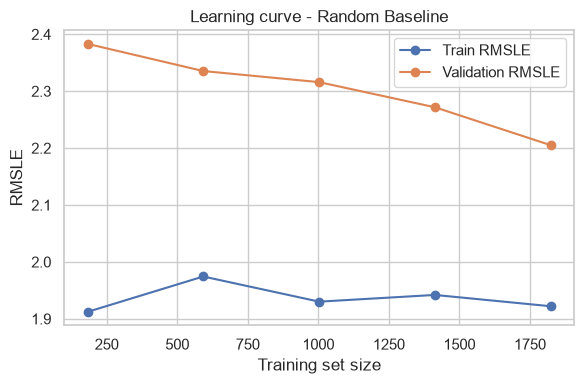

In [141]:
baseline_result = run_kfold_experiment(
    RandomBaselineRegressor(random_state=RANDOM_SEED),
    X_base, y_log, y_count, k=5, model_name="Random Baseline",
)

# 4. Linear Regression

`season` and `month` may be correlated (per the EDA note), and `atemp` is dropped from this feature set due to near-collinearity with `temp`. Interpret the linear coefficients for `season` and `month` with caution.

Linear Regression - train (mean over 5 folds): {'RMSLE': np.float64(1.000160354406918), 'MAE': np.float64(77.0373708557172), 'R2': np.float64(0.2164869278874114)}
Linear Regression - test (mean over 5 folds): {'RMSLE': np.float64(1.079799223291832), 'MAE': np.float64(126.57887587648369), 'R2': np.float64(-0.030368844903513992)}


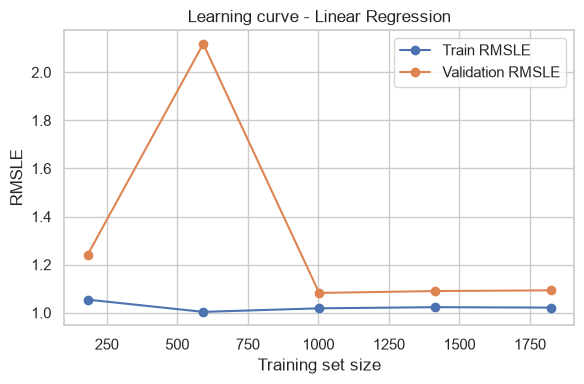

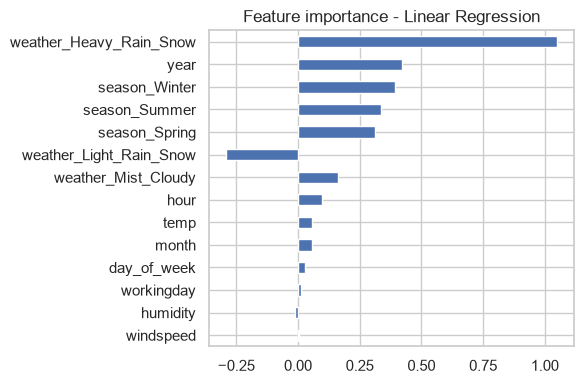

In [142]:
def train_linear_regression(k=5):
    return run_kfold_experiment(
        LinearRegression(), X_linear, y_log, y_count, k=k, model_name="Linear Regression",
    )


linear_regression_result = train_linear_regression()

# 5. Decision Tree Regressor

Conservative, hand-picked hyperparameters (not a tuned/searched optimum) aimed mainly at curbing overfitting: after the day-1-19-per-month fix, this dataset has 10,944 rows total, so `TimeSeriesSplit`'s earliest fold trains on only ~1,800 rows. An unconstrained single tree can easily memorize a sample that small instead of learning the recurring hourly/seasonal pattern, so `max_depth`, `min_samples_leaf`, and `min_samples_split` all cap how specific any single split can get.

Decision Tree - train (mean over 5 folds): {'RMSLE': np.float64(0.5280819830546187), 'MAE': np.float64(47.669473260154305), 'R2': np.float64(0.6601271882028621)}
Decision Tree - test (mean over 5 folds): {'RMSLE': np.float64(0.6978848196127589), 'MAE': np.float64(94.75746633164323), 'R2': np.float64(0.33264101274117375)}


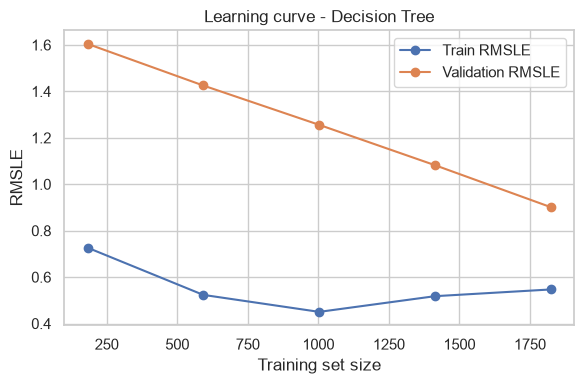

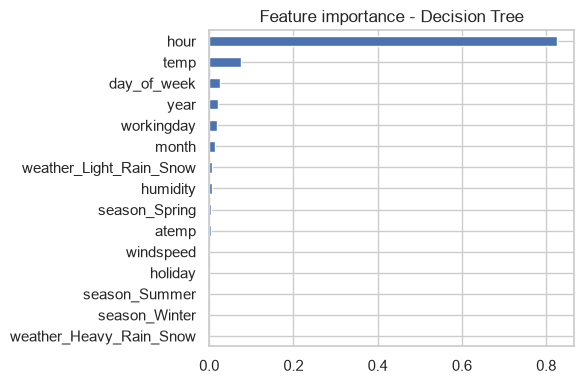

In [143]:
def train_decision_tree(k=5):
    return run_kfold_experiment(
        DecisionTreeRegressor(
            max_depth=6, min_samples_leaf=20, min_samples_split=40,
            random_state=RANDOM_SEED,
        ),
        X_base, y_log, y_count, k=k, model_name="Decision Tree",
    )


decision_tree_result = train_decision_tree()

# 6. Random Forest Regressor

Random Forest - train (mean over 5 folds): {'RMSLE': np.float64(0.31512768570669647), 'MAE': np.float64(20.663246777553248), 'R2': np.float64(0.923208127010251)}
Random Forest - test (mean over 5 folds): {'RMSLE': np.float64(0.5488379045202607), 'MAE': np.float64(71.22939389473352), 'R2': np.float64(0.6002310724295568)}


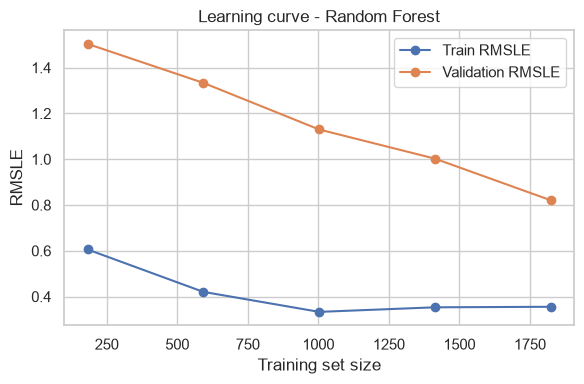

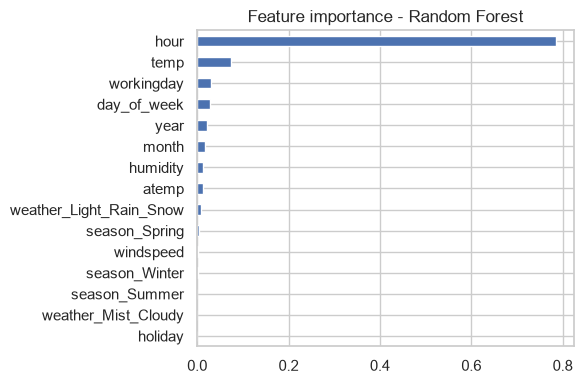

In [144]:
def train_random_forest(k=5):
    return run_kfold_experiment(
        RandomForestRegressor(
            n_estimators=100,  min_samples_leaf=10,
            random_state=RANDOM_SEED,
        ),
        X_base, y_log, y_count, k=k, model_name="Random Forest",
    )


random_forest_result = train_random_forest()

# 7. LightGBM Regressor

Conservative, hand-picked regularization aimed mainly at curbing overfitting: a low `learning_rate` with more boosting rounds (`n_estimators`) learns gradually instead of memorizing; `max_depth`/`num_leaves` and `min_child_samples` cap how specific any single split can get on the small early `TimeSeriesSplit` folds; row/column subsampling (`subsample`/`colsample_bytree`) and L1/L2 penalties (`reg_alpha`/`reg_lambda`) add further regularization.

LightGBM - train (mean over 5 folds): {'RMSLE': np.float64(0.29815114193128267), 'MAE': np.float64(21.30158215277322), 'R2': np.float64(0.930966738048018)}
LightGBM - test (mean over 5 folds): {'RMSLE': np.float64(0.4560020911899965), 'MAE': np.float64(60.33686970652779), 'R2': np.float64(0.7118438757120703)}


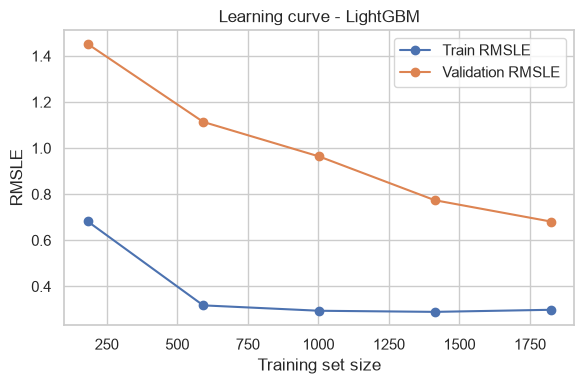

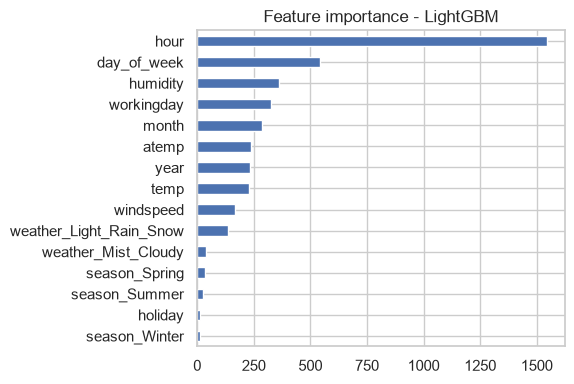

In [145]:
def train_lightgbm(k=5):
    return run_kfold_experiment(
        LGBMRegressor(
            n_estimators=300, learning_rate=0.03, max_depth=5, num_leaves=15,
            min_child_samples=40, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_SEED, verbose=-1,
        ),
        X_base, y_log, y_count, k=k, model_name="LightGBM",
    )


lightgbm_result = train_lightgbm()

# 8. XGBoost Regressor

Same conservative philosophy as the LightGBM section above: a low `learning_rate` with more boosting rounds (`n_estimators`), shallow `max_depth`, a higher `min_child_weight` (XGBoost's leaf-size-like regularization), row/column subsampling (`subsample`/`colsample_bytree`), and explicit L1/L2 penalties (`reg_alpha`/`reg_lambda`) all curb how aggressively each tree can fit the small early `TimeSeriesSplit` folds.

XGBoost - train (mean over 5 folds): {'RMSLE': np.float64(0.25930556263982496), 'MAE': np.float64(19.17485980987549), 'R2': np.float64(0.9447408676147461)}
XGBoost - test (mean over 5 folds): {'RMSLE': np.float64(0.4552509262237262), 'MAE': np.float64(61.194454956054685), 'R2': np.float64(0.6998886704444885)}


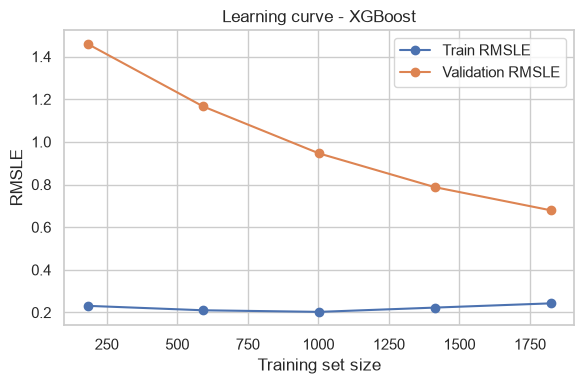

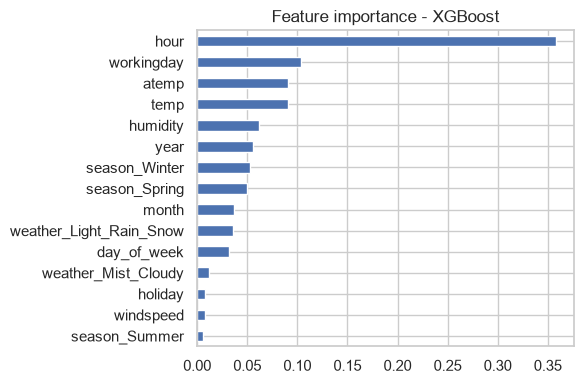

In [146]:
def train_xgboost(k=5):
    return run_kfold_experiment(
        XGBRegressor(
            n_estimators=300, learning_rate=0.03, max_depth=5,
            min_child_weight=10, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_SEED,
        ),
        X_base, y_log, y_count, k=k, model_name="XGBoost",
    )


xgboost_result = train_xgboost()

# 9. Model Metrics Comparison

In [147]:
all_results = [
    baseline_result,
    linear_regression_result,
    decision_tree_result,
    random_forest_result,
    lightgbm_result,
    xgboost_result,
]

records = []
for result in all_results:
    n_folds = len(result["train_metrics"]["RMSLE"])
    for fold in range(n_folds):
        for metric in ["RMSLE", "MAE", "R2"]:
            records.append({
                "model": result["model_name"], "fold": fold, "split": "train",
                "metric": metric, "value": result["train_metrics"][metric][fold],
            })
            records.append({
                "model": result["model_name"], "fold": fold, "split": "test",
                "metric": metric, "value": result["test_metrics"][metric][fold],
            })

metrics_long = pd.DataFrame(records)
metrics_long.head()

,model,fold,split,metric,value
0,Random Baseline,0,train,RMSLE,1.940022
1,Random Baseline,0,test,RMSLE,2.137856
2,Random Baseline,0,train,MAE,82.929825
3,Random Baseline,0,test,MAE,154.311404
4,Random Baseline,0,train,R2,-1.015528


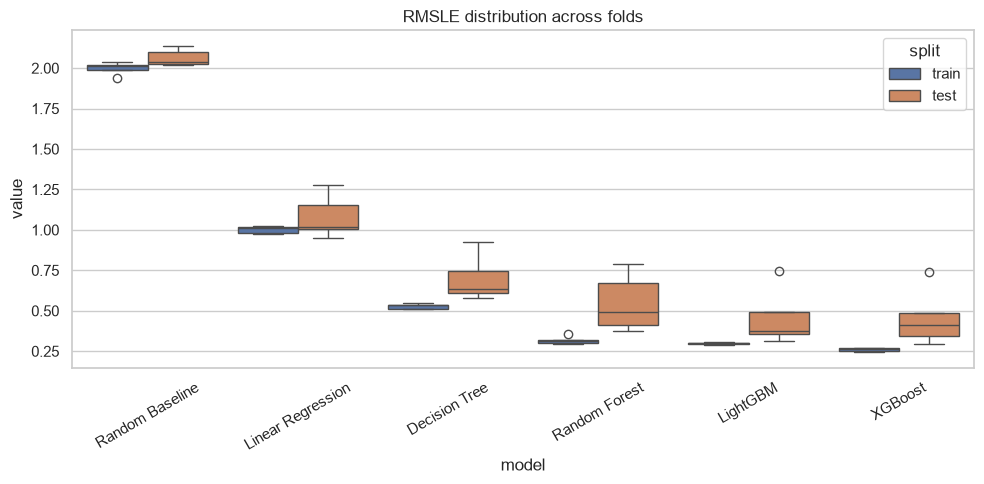

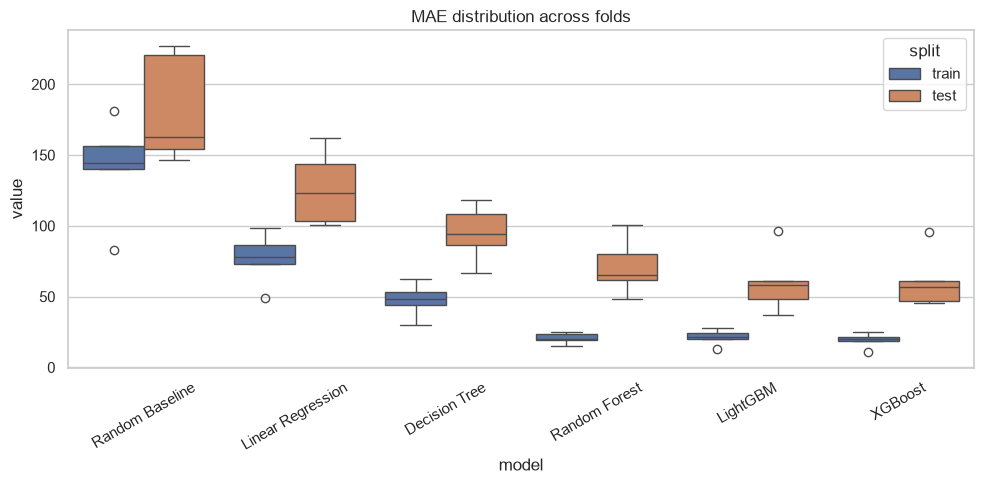

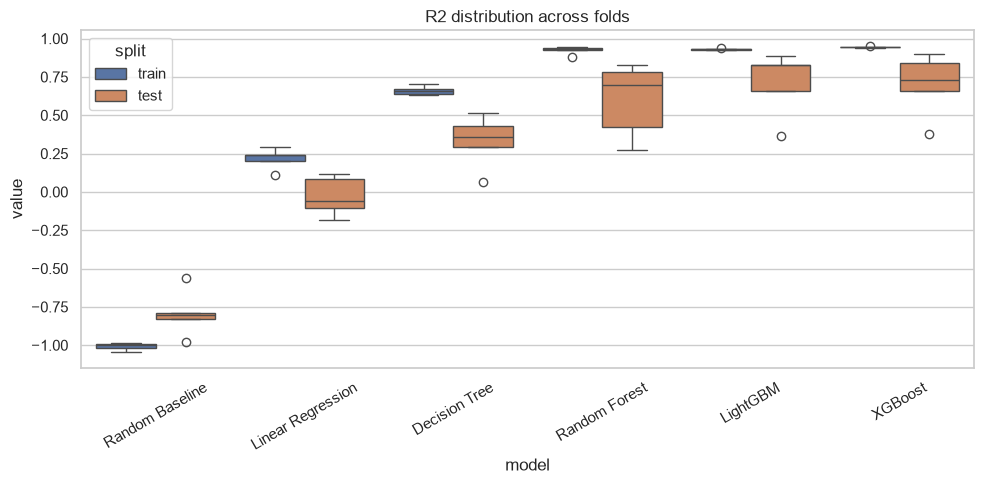

In [148]:
for metric in ["RMSLE", "MAE", "R2"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=metrics_long[metrics_long["metric"] == metric], x="model", y="value", hue="split", ax=ax)
    ax.set_title(f"{metric} distribution across folds")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

## Mean metrics summary

In [149]:
summary_rows = []
for result in all_results:
    row = {"model": result["model_name"]}
    for metric in ["RMSLE", "MAE", "R2"]:
        row[f"train_{metric}"] = result["train_summary"][metric]
        row[f"test_{metric}"] = result["test_summary"][metric]
    summary_rows.append(row)

metrics_summary = pd.DataFrame(summary_rows).set_index("model")
metrics_summary

,train_RMSLE,test_RMSLE,train_MAE,test_MAE,train_R2,test_R2
model,,,,,,
Random Baseline,2.000426,2.063855,141.040057,182.314035,-1.007590,-0.792419
Linear Regression,1.000160,1.079799,77.037371,126.578876,0.216487,-0.030369
Decision Tree,0.528082,0.697885,47.669473,94.757466,0.660127,0.332641
Random Forest,0.315128,0.548838,20.663247,71.229394,0.923208,0.600231
LightGBM,0.298151,0.456002,21.301582,60.336870,0.930967,0.711844
XGBoost,0.259306,0.455251,19.174860,61.194455,0.944741,0.699889


## Prediction bias check

In [150]:
bias_rows = []
for result in all_results:
    mask = result["oof_pred_count"].notna()
    pred = result["oof_pred_count"][mask]
    actual = y_count[mask]
    residual = pred - actual

    bias_rows.append({
        "model": result["model_name"],
        "mean_pred": pred.mean(),
        "mean_actual": actual.mean(),
        "mean_bias": residual.mean(),
        "median_bias": residual.median(),
    })

bias_summary = pd.DataFrame(bias_rows).set_index("model")
bias_summary

,mean_pred,mean_actual,mean_bias,median_bias
model,,,,
Random Baseline,136.432785,212.713706,-76.280921,-57.000000
Linear Regression,160.965628,212.713706,-51.748078,-27.460843
Decision Tree,136.727157,212.713706,-75.986549,-37.001676
Random Forest,151.825938,212.713706,-60.887768,-35.306533
LightGBM,162.060928,212.713706,-50.652779,-26.023956
XGBoost,161.646514,212.713706,-51.067192,-27.829642


## 11. Conclusions
LGBM and XGBoost got the best results. XGBoost's RMSLE is slightly better, but LGBM's MAE and R² is better. Also, its bias is better. So it's the chosen model for this dataset.